<div style="
    background-color: #3D5A73;
    color: white;
    width: 1000px;
    height: 120px;                 /* define altura fixa */
    margin: 20px auto;
    border-radius: 15px;
    display: flex;                 /* ativa flexbox */
    align-items: center;           /* centraliza vertical */
    justify-content: center;       /* centraliza horizontal */
">
    <h1 style="margin: 0;">PARTE II - MODELO PREDITIVO</h1>
</div>

Agora que limpamos o dataset e fizemos a análise exploratória dos dados, está na hora de construir o modelo preditivo.

## Objetivo Principal
Desenvolver um **modelo preditivo** capaz de estimar a probabilidade de inadimplência de cobranças mensais feitas aos clientes.

A **inadimplência** é definida da seguinte forma:
> Um pagamento é considerado inadimplente se for realizado com **5 dias ou mais de atraso** em relação à data de vencimento.

As previsões devem conter apenas a **probabilidade de inadimplência**.

## Estrutura do Projeto
1. **Configurações Iniciais**: Import das bibliotecas que serão utilizadas e visualização do dataset;
2. **Preparação dos Dados para Modelagem**: Feature Enginer das variáveis temporais
3. **Modelagem**: Utilização e comparação de algoritmos de Machine Learning de Classificação; 
4. **Análise do Melhor Modelo**: Estudo sobre o modelo que obteve melhor resultado;
5. **Implementação do Modelo**: Implementação do melhor modelo no dataset de teste;
6. **Conclusão**

<div style="
    background-color: #3D5A73;
    color: white;
    width: 700px;
    height: 120px;                 /* define altura fixa */
    margin: 20px auto;
    border-radius: 15px;
    display: flex;                 /* ativa flexbox */
    align-items: center;           /* centraliza vertical */
    justify-content: center;       /* centraliza horizontal */
">
    <h1 style="margin: 0;">1. Configurações Iniciais</h1>
</div>

## 1.1 Importando Bibliotecas e Dataset

In [1]:
# Import das bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import utils.analysis_utils as func
import utils.model as ml

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

#Configuração padrão do gráfico
plt.style.use('default')

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importando o dataset do teste (submissão)
teste = pd.read_parquet("docs/dataset_teste_limpo.parquet")

# Importando o dataset para treinamento  
df_model = pd.read_parquet("docs/dataset_limpo.parquet")

In [3]:
func.df_summary_report(df_model)


,Coluna,Tipo,Quantidade de Dados Não Vazios,Quantidade de Dados Vazios,Valores Únicos,Valor mais Frequente,Frequência,Porcentagem de Unicidade,Porcentagem de Valor Vazios (%),Consumo de Memória - Total: 14.55 (MB)
0,ID_CLIENTE,int64,77267,0,1226,6964108750473070592.000000,1151,1.59,0.00,0.589500
1,SAFRA_REF,str,77267,0,35,2021-05,2527,0.05,0.00,1.105313
2,DATA_EMISSAO_DOCUMENTO,str,77267,0,1040,2021-05-16,206,1.35,0.00,1.326376
3,DATA_PAGAMENTO,str,77267,0,921,2021-02-17,315,1.19,0.00,1.326376
4,DATA_VENCIMENTO,str,77267,0,955,2019-03-06,357,1.24,0.00,1.326376
5,VALOR_A_PAGAR,float64,77267,0,67564,1182.000000,608,87.44,0.00,0.589500
6,TAXA,float64,77267,0,5,5.990000,26412,0.01,0.00,0.589500
7,RENDA_MES_ANTERIOR,float64,77267,0,17608,236787.500000,315,22.79,0.00,0.589500
8,NO_FUNCIONARIOS,float64,77267,0,128,117.000000,3480,0.17,0.00,0.589500
9,DATA_CADASTRO,str,77267,0,720,2000-08-15,18085,0.93,0.00,1.326376


In [4]:
func.df_summary_report(teste)

,Coluna,Tipo,Quantidade de Dados Não Vazios,Quantidade de Dados Vazios,Valores Únicos,Valor mais Frequente,Frequência,Porcentagem de Unicidade,Porcentagem de Valor Vazios (%),Consumo de Memória - Total: 0.83 (MB)
0,ID_CLIENTE,int64,12275,0,976,1156053485989336481,213,7.95,0.00,0.093651
1,SAFRA_REF,str,12275,0,5,2021-10,2673,0.04,0.00,0.175595
2,DATA_EMISSAO_DOCUMENTO,datetime64[us],12275,0,150,2021-11-04 00:00:00,177,1.22,0.00,0.093651
3,DATA_VENCIMENTO,datetime64[us],12275,0,141,2021-09-06 00:00:00,293,1.15,0.00,0.093651
4,VALOR_A_PAGAR,float64,12275,0,10851,49665.210000,131,88.40,0.00,0.093651
5,TAXA,float64,12275,0,5,5.990000,3937,0.04,0.00,0.093651
6,Mes_Emissao_Documento,int32,12275,0,5,10,2673,0.04,0.00,0.046825
7,Dia_Emissao_Documento,int32,12275,0,31,5,659,0.25,0.00,0.046825
8,Mes_Vencimento,int32,12275,0,11,11,2756,0.09,0.00,0.046825
9,Dia_Vencimento,int32,12275,0,31,6,736,0.25,0.00,0.046825


<div style="
    background-color: #3D5A73;
    color: white;
    width: 800px;
    height: 120px;                 /* define altura fixa */
    margin: 20px auto;
    border-radius: 15px;
    display: flex;                 /* ativa flexbox */
    align-items: center;           /* centraliza vertical */
    justify-content: center;       /* centraliza horizontal */
">
    <h1 style="margin: 0;">2. Preparação dos Dados para Modelagem</h1>
</div>

A preparação dos dados é uma etapa essencial no processo de modelagem em Machine Learning, pois garante que as informações estejam consistentes, limpas e em um formato adequado para os algoritmos. Um bom pré-processamento envolve o tratamento de valores ausentes, a padronização dos tipos de dados, a codificação de variáveis categóricas e a criação de features relevantes. Essa etapa reduz ruídos, evita erros durante o treinamento e aumenta a capacidade do modelo de aprender padrões reais, contribuindo diretamente para um melhor desempenho e maior confiabilidade das previsões.

## 2.1 Manipulação das Datas
A maioria dos algoritmos de Machine Learning (regressão, árvores, redes neurais, SVM etc.) aprende padrões a partir de operações matemáticas como soma, multiplicação, distância e ordenação. Uma data no formato `dd/mm/aaaa` é, na prática, uma string ou um objeto temporal, e não um valor numérico com significado matemático direto para o modelo. Assim, Modelos de Machine Learning não lidam diretamente com datas porque elas não possuem significado matemático imediato. Para que a informação temporal seja aproveitada, é necessário transformá-la em variáveis numéricas que representem padrões relevantes do tempo.

In [5]:
# Transformar colunas object para datetime
cols = ['DATA_EMISSAO_DOCUMENTO', 'DATA_PAGAMENTO', 'DATA_VENCIMENTO']
df_model[cols] = df_model[cols].apply(pd.to_datetime)

# Cálculo da Inadimplência
df_model['Churned'] = np.where(((df_model['DATA_PAGAMENTO'] - df_model['DATA_VENCIMENTO']).dt.days) >= 5, 1, 0)

display(df_model)

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS,DATA_CADASTRO,FLAG_PF,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG,Churned
0,1661240395903230676,2018-08,2018-08-17,2018-09-06,2018-09-06,35516.41,6.99,217640.0,115.0,2013-08-22,Juridico,Serviços,YAHOO,PEQUENO,65,0
1,1661240395903230676,2018-08,2018-08-19,2018-09-11,2018-09-10,17758.21,6.99,217640.0,115.0,2013-08-22,Juridico,Serviços,YAHOO,PEQUENO,65,0
2,1661240395903230676,2018-08,2018-08-26,2018-09-18,2018-09-17,17431.96,6.99,217640.0,115.0,2013-08-22,Juridico,Serviços,YAHOO,PEQUENO,65,0
3,1661240395903230676,2018-08,2018-08-30,2018-10-11,2018-10-05,1341.00,6.99,217640.0,115.0,2013-08-22,Juridico,Serviços,YAHOO,PEQUENO,65,1
4,1661240395903230676,2018-08,2018-08-31,2018-09-20,2018-09-20,21309.85,6.99,217640.0,115.0,2013-08-22,Juridico,Serviços,YAHOO,PEQUENO,65,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77409,2951563549197799278,2021-06,2021-06-30,2021-07-16,2021-07-16,89980.00,5.99,280343.0,161.0,2000-08-15,Juridico,Comércio,AOL,PEQUENO,13,0
77410,5220206408301580591,2021-06,2021-06-30,2021-08-16,2021-08-16,42239.00,5.99,235315.0,87.0,2021-04-08,Juridico,Indústria,GMAIL,GRANDE,25,0
77411,5860276371789140450,2021-06,2021-06-30,2021-07-16,2021-07-16,20921.50,5.99,100006.0,122.0,2011-02-15,Juridico,Serviços,HOTMAIL,GRANDE,67,0
77412,2814790209436551216,2021-06,2021-06-30,2021-07-16,2021-07-16,90231.05,6.99,234489.0,115.0,2021-05-13,Juridico,Serviços,YAHOO,MEDIO,14,0


In [6]:
# Coluna Emissão Documentos
df_model["Mes_Emissao_Documento"] = df_model["DATA_EMISSAO_DOCUMENTO"].dt.month
df_model["Dia_Emissao_Documento"] = df_model["DATA_EMISSAO_DOCUMENTO"].dt.day

# Coluna Mês Vencimento 
df_model["Mes_Vencimento"] = df_model["DATA_VENCIMENTO"].dt.month
df_model["Dia_Vencimento"] = df_model["DATA_VENCIMENTO"].dt.day

# Representação Cílica das Datas (meses próximos → valores próximos)
df_model['mes_venc_sin'] = np.sin(2 * np.pi * df_model['Mes_Vencimento'] / 12)
df_model['mes_venc_cos'] = np.cos(2 * np.pi * df_model['Mes_Vencimento'] / 12)
df_model['dia_venc_sin'] = np.sin(2 * np.pi * df_model['Dia_Vencimento'] / 31)
df_model['dia_venc_cos'] = np.cos(2 * np.pi * df_model['Dia_Vencimento'] / 31)

df_model['dia_semana'] = df_model['DATA_EMISSAO_DOCUMENTO'].dt.weekday
df_model['fim_semana'] = df_model['dia_semana'].isin([5,6]).astype(int)

O mesmo tratamento deve ser feito na base de teste.

In [7]:
# Coluna Emissão Documentos
teste["Mes_Emissao_Documento"] = teste["DATA_EMISSAO_DOCUMENTO"].dt.month
teste["Dia_Emissao_Documento"] = teste["DATA_EMISSAO_DOCUMENTO"].dt.day

# Coluna Mês Vencimento 
teste["Mes_Vencimento"] = teste["DATA_VENCIMENTO"].dt.month
teste["Dia_Vencimento"] = teste["DATA_VENCIMENTO"].dt.day

# Representação Cílica das Datas (meses próximos → valores próximos)
teste['mes_venc_sin'] = np.sin(2 * np.pi * teste['Mes_Vencimento'] / 12)
teste['mes_venc_cos'] = np.cos(2 * np.pi * teste['Mes_Vencimento'] / 12)
teste['dia_venc_sin'] = np.sin(2 * np.pi * teste['Dia_Vencimento'] / 31)
teste['dia_venc_cos'] = np.cos(2 * np.pi * teste['Dia_Vencimento'] / 31)

teste['dia_semana'] = teste['DATA_EMISSAO_DOCUMENTO'].dt.weekday
teste['fim_semana'] = teste['dia_semana'].isin([5,6]).astype(int)

In [8]:
display(df_model)

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS,DATA_CADASTRO,...,Mes_Emissao_Documento,Dia_Emissao_Documento,Mes_Vencimento,Dia_Vencimento,mes_venc_sin,mes_venc_cos,dia_venc_sin,dia_venc_cos,dia_semana,fim_semana
0,1661240395903230676,2018-08,2018-08-17,2018-09-06,2018-09-06,35516.41,6.99,217640.0,115.0,2013-08-22,...,8,17,9,6,-1.000000,-1.836970e-16,0.937752,0.347305,4,0
1,1661240395903230676,2018-08,2018-08-19,2018-09-11,2018-09-10,17758.21,6.99,217640.0,115.0,2013-08-22,...,8,19,9,10,-1.000000,-1.836970e-16,0.897805,-0.440394,6,1
2,1661240395903230676,2018-08,2018-08-26,2018-09-18,2018-09-17,17431.96,6.99,217640.0,115.0,2013-08-22,...,8,26,9,17,-1.000000,-1.836970e-16,-0.299363,-0.954139,6,1
3,1661240395903230676,2018-08,2018-08-30,2018-10-11,2018-10-05,1341.00,6.99,217640.0,115.0,2013-08-22,...,8,30,10,5,-0.866025,5.000000e-01,0.848644,0.528964,3,0
4,1661240395903230676,2018-08,2018-08-31,2018-09-20,2018-09-20,21309.85,6.99,217640.0,115.0,2013-08-22,...,8,31,9,20,-1.000000,-1.836970e-16,-0.790776,-0.612106,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77409,2951563549197799278,2021-06,2021-06-30,2021-07-16,2021-07-16,89980.00,5.99,280343.0,161.0,2000-08-15,...,6,30,7,16,-0.500000,-8.660254e-01,-0.101168,-0.994869,2,0
77410,5220206408301580591,2021-06,2021-06-30,2021-08-16,2021-08-16,42239.00,5.99,235315.0,87.0,2021-04-08,...,6,30,8,16,-0.866025,-5.000000e-01,-0.101168,-0.994869,2,0
77411,5860276371789140450,2021-06,2021-06-30,2021-07-16,2021-07-16,20921.50,5.99,100006.0,122.0,2011-02-15,...,6,30,7,16,-0.500000,-8.660254e-01,-0.101168,-0.994869,2,0
77412,2814790209436551216,2021-06,2021-06-30,2021-07-16,2021-07-16,90231.05,6.99,234489.0,115.0,2021-05-13,...,6,30,7,16,-0.500000,-8.660254e-01,-0.101168,-0.994869,2,0


In [9]:
display(teste)

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA,Mes_Emissao_Documento,Dia_Emissao_Documento,Mes_Vencimento,Dia_Vencimento,mes_venc_sin,mes_venc_cos,dia_venc_sin,dia_venc_cos,dia_semana,fim_semana
0,5058298901476893676,2021-07,2021-07-14,2021-08-04,11204.75,4.99,7,14,8,4,-8.660254e-01,-5.000000e-01,0.724793,0.688967,2,0
1,274692171162531764,2021-07,2021-07-08,2021-08-23,60718.50,5.99,7,8,8,23,-8.660254e-01,-5.000000e-01,-0.998717,-0.050649,3,0
2,274692171162531764,2021-07,2021-07-11,2021-08-25,60718.50,5.99,7,11,8,25,-8.660254e-01,-5.000000e-01,-0.937752,0.347305,6,1
3,274692171162531764,2021-07,2021-07-16,2021-08-30,62250.00,5.99,7,16,8,30,-8.660254e-01,-5.000000e-01,-0.201299,0.979530,4,0
4,465309249432033993,2021-07,2021-07-05,2021-07-30,26593.95,6.99,7,5,7,30,-5.000000e-01,-8.660254e-01,-0.201299,0.979530,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12270,705648002974742140,2021-11,2021-11-25,2021-12-13,47010.00,6.99,11,25,12,13,-2.449294e-16,1.000000e+00,0.485302,-0.874347,3,0
12271,4993499380140734678,2021-11,2021-11-25,2021-12-13,122875.35,8.99,11,25,12,13,-2.449294e-16,1.000000e+00,0.485302,-0.874347,3,0
12272,4614484019183480654,2021-11,2021-11-26,2028-09-30,302200.00,5.99,11,26,9,30,-1.000000e+00,-1.836970e-16,-0.201299,0.979530,4,0
12273,1299146298565441811,2021-11,2021-11-26,2021-12-13,143791.85,5.99,11,26,12,13,-2.449294e-16,1.000000e+00,0.485302,-0.874347,4,0


## 2.2 Dados Desbalanceados

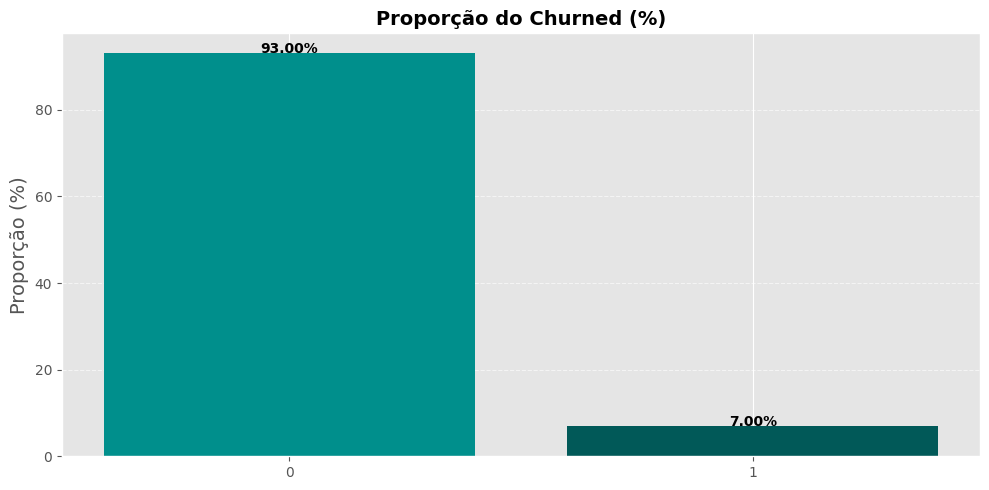

In [10]:
func.plot_proportion_bar(df_model, column="Churned")

No conjunto de dados esta desbalanceado, 93% são de clientes considerados bons pagadores e apenas 7% são considerados inadimplentes, em outras palavras, qualquer tentativa de construir um modelo preditivo irá favorecer a classe majoritária, dificultanto o objetivo central deste projeto.

> *Mas porque isso acontece?* 
>
> **Dados desbalanceados** ocorrem quando as classes em um conjunto de dados não estão representadas de forma igual, apresentando uma disparidade significativa entre a classe majoritária e a classe minoritária. Esse desbalanceamento pode influenciar diretamente na construção e avaliação do modelo de machine learning. Durante a modelagem, algoritmos tendem a aprender padrões da classe majoritária, pois ela domina o processo de otimização. Como consequência, o modelo pode apresentar uma alta acurácia, mas ainda assim falhar em identificar corretamente a classe minoritária, que geralmente é a mais relevante do ponto de vista de negócio.

Na análise dos resultados, métricas como **accuracy** tornam-se pouco informativas em cenários desbalanceados, pois um modelo pode obter bons valores simplesmente prevendo sempre a classe mais frequente. Por esse motivo, é fundamental priorizar métricas mais adequadas, como **recall, precision, F1-score e ROC-AUC**, que oferecem uma visão mais equilibrada do desempenho do modelo sobre ambas as classes.
- **Precision, Recall**: Ideal para quando a classe positiva é rara.
- **F1-Score**: Balanço entre precisão e sensibilidade.
- **Matriz de Confusão**: Para visualizar onde o modelo está errando.
- **AUC-ROC**: Avalia a capacidade de distinção entre as classes. 

Para lidar com dados desbalanceados, existem diversas estratégias. Uma abordagem comum é o reajuste da distribuição das classes, que pode ser feito por meio de técnicas como:
- **Undersampling**, nas quais **amostras da classe majoritária são removidas**, ou 
- **Oversampling**, em que **novas observações da classe minoritária são geradas artificialmente**. 

Técnicas como o SMOTE (Synthetic Minority Over-sampling Technique) são amplamente utilizadas nesse contexto, pois criam novos exemplos sintéticos com base nos vizinhos mais próximos da classe minoritária, reduzindo o risco de overfitting quando comparadas ao simples aumento por duplicação de dados.

Neste projeto, serão avaliados cinco modelos de Machine Learning: **Regressão Logística, Random Forest, Árvore de Decisão, K-Nearest Neighbors (KNN) e LightGBM**. Esses algoritmos são amplamente usados em modelos de classificação e apresentam abordagens distintas para a construção de modelos preditivos, permitindo uma análise comparativa de desempenho com base em diferentes métricas de avaliação, como acurácia, precisão, recall, F1-score e ROC-AUC.

> **ATENÇÃO**: No primeiro momento irei validar os modelos utilizados com base no dataset `df_model`, depois de avaliar os modelos irei implementar o que tiver melhor resultado no dataset de `teste`. 

## 2.3 Divisão em treino e Teste

In [11]:
# Divisão entre target e o que será usado no modelo
X = df_model.drop(['ID_CLIENTE', 'SAFRA_REF', 'DATA_PAGAMENTO','DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO','RENDA_MES_ANTERIOR', 
                   'NO_FUNCIONARIOS', 'DATA_CADASTRO', 'SEGMENTO_INDUSTRIAL', 'FLAG_PF', 'DOMINIO_EMAIL', 'PORTE', 'CEP_2_DIG', 'Churned'], axis=1)
y = df_model['Churned']

# Divisão entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state = 42)


<div style="
    background-color: #3D5A73;
    color: white;
    width: 800px;
    height: 120px;                 /* define altura fixa */
    margin: 20px auto;
    border-radius: 15px;
    display: flex;                 /* ativa flexbox */
    align-items: center;           /* centraliza vertical */
    justify-content: center;       /* centraliza horizontal */
">
    <h1 style="margin: 0;">3. Modelagem</h1>
</div>

Nesta seção, iniciaremos com o treinamento dos modelos e a comparação das métricas de avaliação sem a aplicação de técnicas específicas de tratamento nos dados de treino e teste. O objetivo é utilizar esses resultados como benchmark, servindo como referência para avaliar o impacto das técnicas voltadas ao tratamento do desbalanceamento de dados que serão aplicadas nas etapas seguintes.

In [12]:
df_benchmark = ml.train_and_compare_models(X_train = X_train, X_test = X_test, y_train = y_train, y_test = y_test)
df_benchmark.sort_values('Recall', ascending = False).style.format("{:.3f}", subset = df_benchmark.select_dtypes(include="number").columns).background_gradient(cmap='Blues')

,Modelo,ROC-AUC,Accuracy,Precision,Recall,F1-Score
3,Árvore de Decisão,0.667,0.904,0.329,0.361,0.344
1,Floresta Randômica,0.853,0.941,0.653,0.328,0.437
2,K-Vizinhos Mais Próximos (KNN),0.702,0.930,0.506,0.206,0.293
4,LightGBM,0.838,0.938,0.690,0.202,0.312
0,Regressão Logística,0.671,0.930,0.000,0.000,0.000


Após o treinamento dos cinco modelos, observou-se que a **Árvore de Decisão** apresentou o melhor desempenho ao analisar a métrica de `Recall`. Diante desse resultado, o próximo passo será a aplicação de uma estratégia de validação cruzada combinada com o RepeatedStratifiedKFold, com o objetivo de obter estimativas de desempenho mais robustas e, potencialmente, melhorar os resultados do modelo.

## 3.1 Validação Cruzada + RepeatedStratifiedKFold
Agora avançaremos para técnicas voltadas ao tratamento de dados desbalanceados. Primeiramente, será utilizada a **Validação Cruzada K-Fold**, uma abordagem fundamental em Machine Learning para avaliar o desempenho de modelos preditivos por meio da divisão do conjunto de dados em múltiplos subconjuntos de treino e teste. Esse processo é repetido diversas vezes, permitindo uma avaliação mais consistente da capacidade de generalização do modelo e auxiliando na detecção de sobreajuste (overfitting).

No entanto, em cenários de desbalanceamento de classes, a utilização do `RepeatedStratifiedKFold` se mostra mais adequada. Essa técnica combina a estratificação das classes, preservando a proporção da variável alvo em cada fold, com múltiplas repetições do processo de validação cruzada, utilizando diferentes embaralhamentos aleatórios a cada iteração.

In [ ]:
# Processo leva aproximadamente 8 minutos 
df_cross_val = ml.train_cv_repeat(X, y)
df_cross_val.sort_values('Recall', ascending = False).style.format("{:.3f}", subset = df_cross_val.select_dtypes(include="number").columns).background_gradient(cmap='Blues')

,Modelo,ROC-AUC,Accuracy,Precision,Recall,F1-Score
3,Árvore de Decisão,0.665,0.905,0.336,0.361,0.348
1,Floresta Randômica,0.849,0.941,0.651,0.324,0.433
2,K-Vizinhos Mais Próximos (KNN),0.699,0.930,0.507,0.198,0.285
4,LightGBM,0.835,0.938,0.698,0.194,0.303
0,Regressão Logística,0.677,0.930,0.000,0.000,0.000


Observa-se uma melhoria geral nos resultados após a aplicação das técnicas propostas, enquanto a Regressão Logística continuou apresentando os piores desempenhos entre os modelos avaliados.

Embora o modelo de **Árvore de Decisão** apresente bons resultados em termos de `Recall`, é importante analisar com atenção o comportamento da **Floresta Randômica**. Apesar de ocupar a segunda posição quando se considera apenas essa métrica, o modelo se destaca pelo equilíbrio entre as outras métricas, apresentando `Precision` de 0,65 e `ROC-AUC` de 0,845, o que indica uma boa capacidade discriminativa e um desempenho mais consistente no contexto geral.

## 3.2 Oversampling e Undersampling
A segunda técnica adotada será o SMOTE (Synthetic Minority Over-sampling Technique), amplamente utilizada para lidar com conjuntos de dados desbalanceados em Machine Learning. Essa abordagem atua aumentando a representatividade da classe minoritária por meio da geração de amostras sintéticas. Ao criar novos exemplos com base nos vizinhos mais próximos da classe minoritária, o SMOTE contribui para reduzir o risco de sobreajuste (overfitting), um problema comum em técnicas tradicionais de oversampling, além de favorecer uma melhor capacidade de generalização dos modelos.

In [ ]:
# Processo leva aproximadamente 3 minuto
df_padrao, modelos_padrao = ml.validacao_cruzada(X, y)
df_padrao.sort_values('Recall', ascending = False).style.format("{:.3f}", subset = df_padrao.select_dtypes(include="number").columns).background_gradient(cmap='Blues')

,Modelo,ROC-AUC,Accuracy,Precision,Recall,F1-Score
3,Árvore de Decisão,0.664,0.905,0.334,0.362,0.347
1,Floresta Randômica,0.850,0.940,0.650,0.317,0.426
2,K-Vizinhos Mais Próximos (KNN),0.697,0.930,0.505,0.197,0.283
4,LightGBM,0.834,0.938,0.694,0.192,0.300
0,Regressão Logística,0.675,0.930,0.000,0.000,0.000


Uma diferença importante observada nesses resultados está no fato de que, nesta etapa, foi utilizado o `StratifiedKFold` em vez do `RepeatedStratifiedKFold`. A principal distinção entre essas abordagens está no **número de vezes em que o processo de validação cruzada é executado**, o que impacta diretamente a estabilidade e a robustez da avaliação do modelo, especialmente em conjuntos de dados pequenos ou desbalanceados.

- **StratifiedKFold**: divide o conjunto de dados em k subconjuntos (*folds*) uma única vez, garantindo que cada fold preserve a mesma proporção de classes observada no conjunto original por meio da estratificação.
- **RepeatedStratifiedKFold**: repete o processo de StratifiedKFold por múltiplas iterações (*n_repeats*), utilizando diferentes embaralhamentos aleatórios em cada repetição, o que resulta em estimativas de desempenho mais estáveis e menos sensíveis à variabilidade amostral.


In [ ]:
# Processo leva aproximandamente 6 minutos
df_com_over, modelos_over = ml.validacao_cruzada(X, y, oversampling = True)
df_com_over.sort_values('Recall', ascending = False).style.format("{:.3f}", subset = df_com_over.select_dtypes(include="number").columns).background_gradient(cmap='Blues')

,Modelo,ROC-AUC,Accuracy,Precision,Recall,F1-Score
0,Regressão Logística,0.603,0.597,0.095,0.556,0.162
2,K-Vizinhos Mais Próximos (KNN),0.689,0.757,0.151,0.536,0.236
3,Árvore de Decisão,0.674,0.905,0.341,0.389,0.363
1,Floresta Randômica,0.847,0.938,0.594,0.377,0.461
4,LightGBM,0.825,0.935,0.572,0.270,0.367


O aumento excessivo do `Recall` observada na **Regressão Logística** após um Oversampling é um efeito clássico de **overfitting** (sobreajuste) na classe minoritária. Isso ocorre porque o modelo aprendeu a "decorar" os exemplos sintéticos ou duplicados da classe minoritária em vez de aprender padrões gerais, tornando-o propenso para classificar qualquer dado novo como a classe minoritária. 

In [ ]:
# Processo leva pouco mais de 3 minuto
df_com_under, modelos_under = ml.validacao_cruzada(X, y, undersampling=True)
df_com_under.sort_values('Recall', ascending = False).style.format("{:.3f}", subset = df_com_under.select_dtypes(include="number").columns).background_gradient(cmap='Blues')

,Modelo,ROC-AUC,Accuracy,Precision,Recall,F1-Score
3,Árvore de Decisão,0.673,0.904,0.334,0.380,0.356
1,Floresta Randômica,0.850,0.940,0.632,0.351,0.451
2,K-Vizinhos Mais Próximos (KNN),0.700,0.929,0.484,0.228,0.310
4,LightGBM,0.835,0.937,0.651,0.225,0.335
0,Regressão Logística,0.677,0.930,0.000,0.000,0.000


Após aplicar a técnica de Undersampling, observa-se que os modelos de **Árvore de Decisão** e **Floresta Randômica** apresentaram os melhores desempenhos. No entanto, a Floresta Randômica demonstrou maior estabilidade e equilíbrio entre as métricas, destacando-se por uma **Accuracy** elevada, além de **Precision, F1-Score** e **ROC-AUC** superiores em comparação à Árvore de Decisão.

Na avaliação de modelos de Machine Learning, é fundamental analisar o conjunto de métricas e não apenas uma métrica isolada. Embora a Árvore de Decisão apresente melhor **Recall**, esse resultado vem acompanhado de uma **Precision** baixa, o que indica um maior número de falsos positivos, um aspecto crítico em problemas de inadimplência.

Dessa forma, considerando as métricas e o impacto prático do modelo no contexto do problema, a **Floresta Randômica** foi o modelo que apresentou o melhor desempenho geral, sendo a escolha mais adequada para este cenário.

<div style="
    background-color: #3D5A73;
    color: white;
    width: 800px;
    height: 120px;                 /* define altura fixa */
    margin: 20px auto;
    border-radius: 15px;
    display: flex;                 /* ativa flexbox */
    align-items: center;           /* centraliza vertical */
    justify-content: center;       /* centraliza horizontal */
">
    <h1 style="margin: 0;">4. Análise do Melhor Modelo</h1>
</div>

Com o modelo de melhor desempenho selecionado, o próximo passo consiste em analisar seu comportamento por meio do Relatório de Classificação, da Matriz de Confusão e da Curva ROC. Essas ferramentas permitem uma avaliação detalhada do desempenho do modelo, fornecendo uma visão complementar às métricas agregadas. 

O **Relatório de Classificação** resume métricas como Precision, Recall e F1-Score para cada classe, a **Matriz de Confusão** evidencia os acertos e erros do modelo, enquanto a **Curva ROC** avalia sua capacidade de discriminação entre as classes em diferentes limiares de decisão. Em conjunto, essas análises possibilitam uma compreensão mais completa e interpretável de como o modelo se comporta na prática.

In [17]:
# pegar apenas o modelo desejado
rf_model = modelos_under["Floresta Randômica"]

# usar em novos dados
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

In [18]:
rf_report = classification_report(y_test, y_pred)
print("Relatório de Classificação para Random Forest (Undersampling):")
print(rf_report)

Relatório de Classificação para Random Forest (Undersampling):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14373
           1       0.95      0.96      0.96      1081

    accuracy                           0.99     15454
   macro avg       0.98      0.98      0.98     15454
weighted avg       0.99      0.99      0.99     15454



A partir do **Relatório de Classificação**, observa-se que o modelo de **Random Forest** com **Undersampling** apresenta um excelente desempenho na distinção entre as classes 0 e 1. O modelo alcança valores elevados de **Precision, Recall** e **F1-Score** para ambas as classes, indicando uma alta capacidade de identificar corretamente tanto clientes adimplentes quanto inadimplentes.

Em especial, o Recall da classe 1 (inadimplentes) é de 0,96, o que significa que o modelo consegue identificar corretamente a grande maioria dos clientes inadimplentes, reduzindo significativamente a ocorrência de falsos negativos, um aspecto crítico para o problema de negócio.

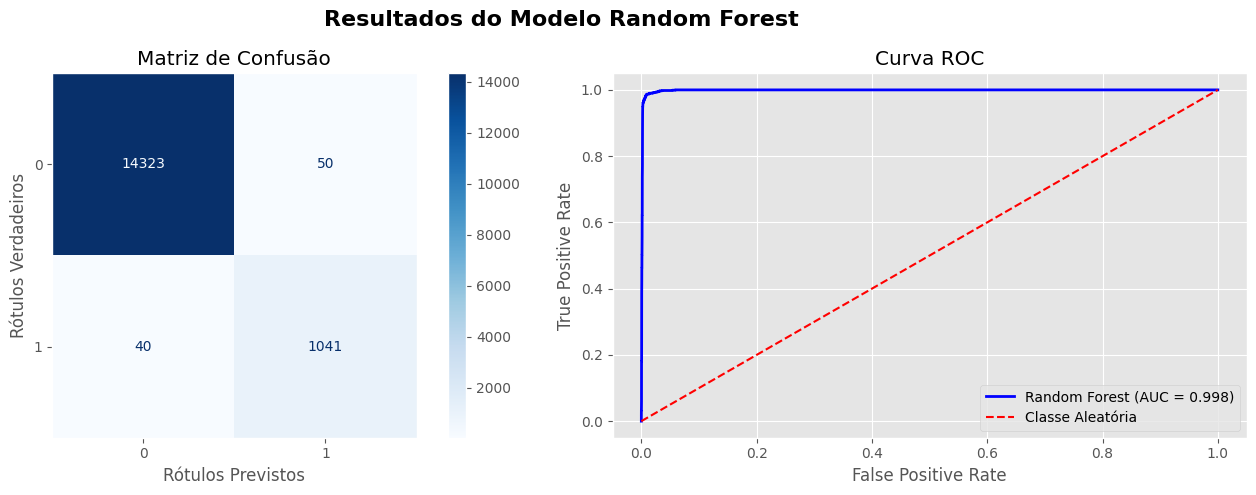

In [19]:
# ---- MÉTRICAS ----
cm = confusion_matrix(y_test, y_pred)
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, threshold = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

# ---- FIGURA COM 2 SUBPLOTS ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Resultados do Modelo Random Forest", fontsize=16, fontweight="bold")

# ---- SUBPLOT 1: MATRIZ DE CONFUSÃO ----
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[0], cmap=plt.cm.Blues, colorbar=True)
axes[0].set_title("Matriz de Confusão")
axes[0].set_xlabel("Rótulos Previstos")
axes[0].set_ylabel("Rótulos Verdadeiros")
axes[0].grid(False)

# ---- SUBPLOT 2: CURVA ROC ----
axes[1].plot(fpr, tpr, color="blue", linewidth=2, label=f"Random Forest (AUC = {auc_score:.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="red", label="Classe Aleatória")

axes[1].set_title("Curva ROC")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

A análise da Matriz de Confusão e da Curva ROC reforça os resultados observados no Relatório de Classificação. O modelo de Random Forest com Undersampling demonstra uma excelente capacidade de distinção entre as classes 0 e 1, evidenciada pelo baixo número de falsos positivos e falsos negativos, bem como pelo bom comportamento da Curva ROC.

Esses resultados indicam que o modelo apresenta uma alta capacidade discriminativa, conseguindo separar adequadamente clientes adimplentes e inadimplentes em diferentes limiares de decisão, o que reforça sua robustez e confiabilidade para aplicação prática.

<div style="
    background-color: #3D5A73;
    color: white;
    width: 800px;
    height: 120px;                 /* define altura fixa */
    margin: 20px auto;
    border-radius: 15px;
    display: flex;                 /* ativa flexbox */
    align-items: center;           /* centraliza vertical */
    justify-content: center;       /* centraliza horizontal */
">
    <h1 style="margin: 0;">5. Implementação do Melhor Modelo</h1>
</div>

## 5.1 Avaliando no Conjunto de Teste
Nesta etapa, o modelo será avaliado utilizando o conjunto de dados `base_pagamentos_teste.csv`. Será aplicado o modelo de Random Forest previamente treinado para gerar as probabilidades de inadimplência de cada cliente.

Por fim, essas previsões serão utilizadas para a criação do arquivo de `submissão`, contendo as probabilidades estimadas conforme o formato exigido.

In [20]:
# Separando as colunas que usarei para submissão do modelo
X_teste = teste.drop(['ID_CLIENTE', 'SAFRA_REF', 'DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO'], axis=1)

# Utilizando o RandomForestClassifier na base de teste
y_pred = rf_model.predict(X_teste)

# Calculando a probabilidade de cada evento
y_broba = rf_model.predict_proba(X_teste)[:,1]

# Criando um nova coluna com a brobalidade das previsões e a inadimplência na base de teste 
teste['Inadimplencia'] = y_pred
teste['Probalidade %'] = y_broba

# Criando o dataset para submissão
resultado = teste[['ID_CLIENTE', 'SAFRA_REF', 'Probalidade %']]

In [21]:
display(resultado)

,ID_CLIENTE,SAFRA_REF,Probalidade %
0,5058298901476893676,2021-07,0.046667
1,274692171162531764,2021-07,0.026667
2,274692171162531764,2021-07,0.260000
3,274692171162531764,2021-07,0.030000
4,465309249432033993,2021-07,0.010000
...,...,...,...
12270,705648002974742140,2021-11,0.026667
12271,4993499380140734678,2021-11,0.006667
12272,4614484019183480654,2021-11,0.260000
12273,1299146298565441811,2021-11,0.013333


In [22]:
# Salvando o dataset 
resultado.to_csv('docs/resultado_final.csv', index=False)

## 5.2 Distribuição das Probabilidades Previstas
Esse tipo de gráfico mostra como o modelo distribui as probabilidades previstas para cada classe. Quando as distribuições das classes **ficam bem separadas** isso indica que o modelo possui alto poder discriminativo, mas se houver muita sobreposição, significa que o modelo tem dificuldade em distinguir as classes.  

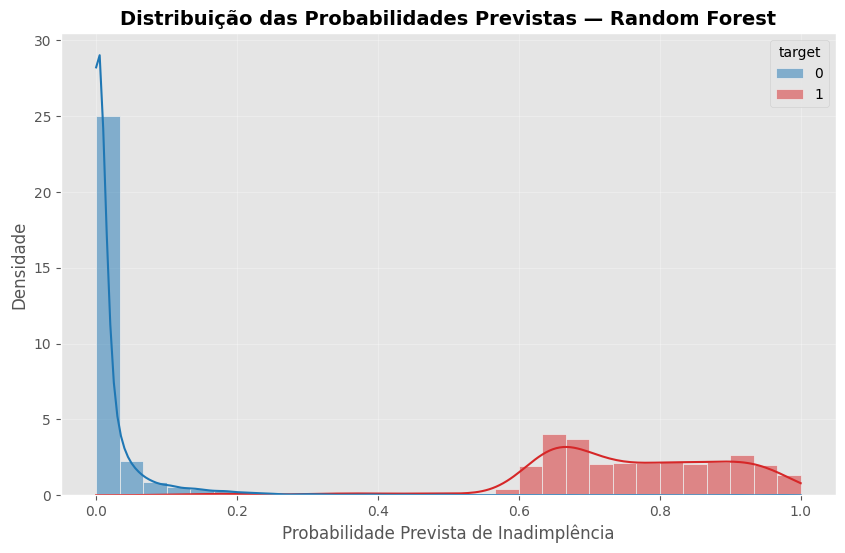

In [23]:
# Calculando a probabilidade de cada evento
y_broba_forest = rf_model.predict_proba(X_test)[:,1]

# Criar dataframe auxiliar para facilitar
df_plot = pd.DataFrame({
    "probabilidade": y_broba_forest,
    "target": y_test.reset_index(drop=True)
})

plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_plot,
    x="probabilidade",
    hue="target",
    bins=30,
    kde=True,
    stat="density",
    common_norm=False,  # muito importante: não normalizar junto as classes!!
    palette=["#1f77b4", "#d62728"]  # azul (0) e vermelho (1)
)

plt.title("Distribuição das Probabilidades Previstas — Random Forest", fontsize=14, fontweight="bold")
plt.xlabel("Probabilidade Prevista de Inadimplência")
plt.ylabel("Densidade")
plt.grid(alpha=0.3)
plt.show()

Este gráfico mostra a distribuição das probabilidades previstas de inadimplência geradas pelo modelo de **Random Forest**, separadas por classe real:
- Classe 0 (azul) → clientes adimplentes
- Classe 1 (vermelho) → clientes inadimplentes

Nota-se uma boa separação entre as distribuições, os **clientes adimplentes** (classe 0) concentram-se fortemente em probabilidades próximas de 0, indicando que o modelo atribui baixo risco de inadimplência para esses casos. já para os clientes inadimplentes (classe 1) apresentam probabilidades majoritariamente acima de 0.6, com concentração entre 0.7 e 1.0, o que indica alta confiança do modelo ao identificar clientes de risco.

Na região entre 0.2 e 0.5, existe uma zona de sobreposição, alguns clientes adimplentes recebem probabilidade moderada outros recebem uma probabilidade menor.

EM resumo, o gráfico apresenta boa capacidade de separação entre clientes adimplentes e inadimplentes. A distribuição das probabilidades reforça a robustez do modelo e oferece flexibilidade para ajustes estratégicos do limiar de decisão conforme o apetite ao risco da instituição.

<div style="
    background-color: #3D5A73;
    color: white;
    width: 800px;
    height: 120px;                 /* define altura fixa */
    margin: 20px auto;
    border-radius: 15px;
    display: flex;                 /* ativa flexbox */
    align-items: center;           /* centraliza vertical */
    justify-content: center;       /* centraliza horizontal */
">
    <h1 style="margin: 0;">Conclusão</h1>
</div>

O objetivo deste projeto foi desenvolver um modelo preditivo capaz de estimar a probabilidade de inadimplência de clientes, voltado para uma empresa de consultoria especializada em soluções de dados e inteligência de crédito.

Foi realizada a construção e avaliação dos modelos preditivos, incluindo Regressão Logística, Árvore de Decisão, Random Forest, K-Nearest Neighbors (KNN) e LightGBM. Durante essa etapa, foi identificado um problema de desbalanceamento entre as classes, uma vez que a classe majoritária se sobressaía em relação à classe minoritária. Para lidar com esse desafio, foram aplicadas e comparadas diferentes estratégias, como undersampling, oversampling e validação cruzada, sempre considerando métricas alinhadas ao contexto do negócio.

Em resumo, mesmo diante do desbalanceamento dos dados, o modelo de Random Forest apresentou o melhor desempenho geral, destacando-se pelo equilíbrio entre as métricas de avaliação e pela sua capacidade de discriminar adequadamente clientes adimplentes e inadimplentes, tornando-se a solução mais adequada para o problema proposto.
